# Clinical Risk Stratification System: A Neuro-Fuzzy (ANFIS) Approach

This notebook outlines the implementation of an **Adaptive Neuro-Fuzzy Inference System (ANFIS)** designed to predict cardiovascular risk from patient vitals. 

---



## Section 1: Project Overview & Setup
In healthcare, transparency is as critical as accuracy. While deep neural networks often act as "Black Boxes," fuzzy logic systems provide human-interpretable "IF-THEN" rules. ANFIS (Adaptive Neuro-Fuzzy Inference System) combines these worlds: it uses the learning capabilities of a neural network to tune the membership functions of a fuzzy inference engine.

In this notebook, we will:
1. Generate synthetic clinical data (Age, Blood Pressure, Cholesterol).
2. Define a baseline Fuzzy Inference System (FIS).
3. Use SciPy optimization to "learn" better membership function parameters.
4. Prove explainability by inspecting triggered clinical rules.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import skfuzzy as fuzzy
from skfuzzy import control as ctrl
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Inline plotting
%matplotlib inline

# Style configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

## Section 2: Data Loading & Exploratory Data Analysis (EDA)
To ensure this notebook is standalone, we generate a synthetic dataset representing **300 patients**. 
- **Age**: 20 to 100 years.
- **Blood Pressure (trestbps)**: 90 to 200 mmHg.
- **Cholesterol**: 100 to 400 mg/dL.
- **Target (Risk)**: A calculated risk score influenced by these vitals with added Gaussian noise.



Dataset Preview:


,age,blood_pressure,cholesterol,risk_score
0,71,113,280,45.990770
1,34,182,141,37.348772
2,91,135,285,68.622999
3,80,142,322,68.554607
4,40,184,221,71.840293


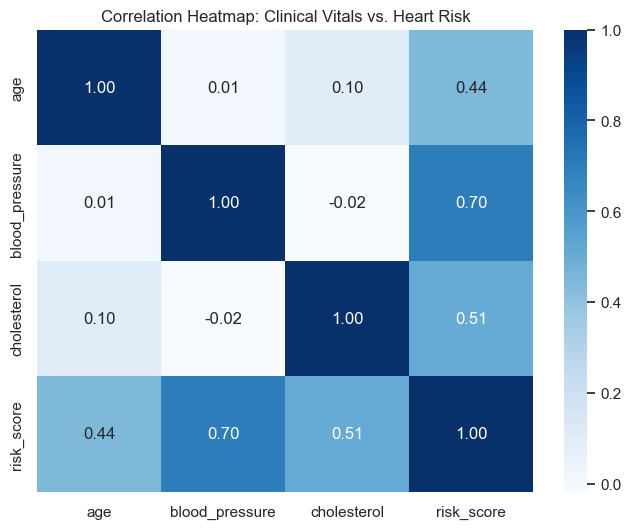

In [2]:
# Seed for reproducibility
np.random.seed(42)

# Generate 300 rows of physiological data
n_samples = 300
age = np.random.randint(20, 101, n_samples)
bp = np.random.randint(90, 201, n_samples)
chol = np.random.randint(100, 401, n_samples)

# Simple risk relationship with some noise
# Logic: Risk increases with age, higher BP, and higher cholesterol
raw_risk = (age * 0.3) + (bp * 0.4) + (chol * 0.1)
noise = np.random.normal(0, 5, n_samples)
risk_score = (raw_risk + noise)

# Scale risk to 0-100 range
risk_score = 100 * (risk_score - risk_score.min()) / (risk_score.max() - risk_score.min())

df = pd.DataFrame({
    'age': age,
    'blood_pressure': bp,
    'cholesterol': chol,
    'risk_score': risk_score
})

print("Dataset Preview:")
display(df.head())

# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title("Correlation Heatmap: Clinical Vitals vs. Heart Risk")
plt.show()


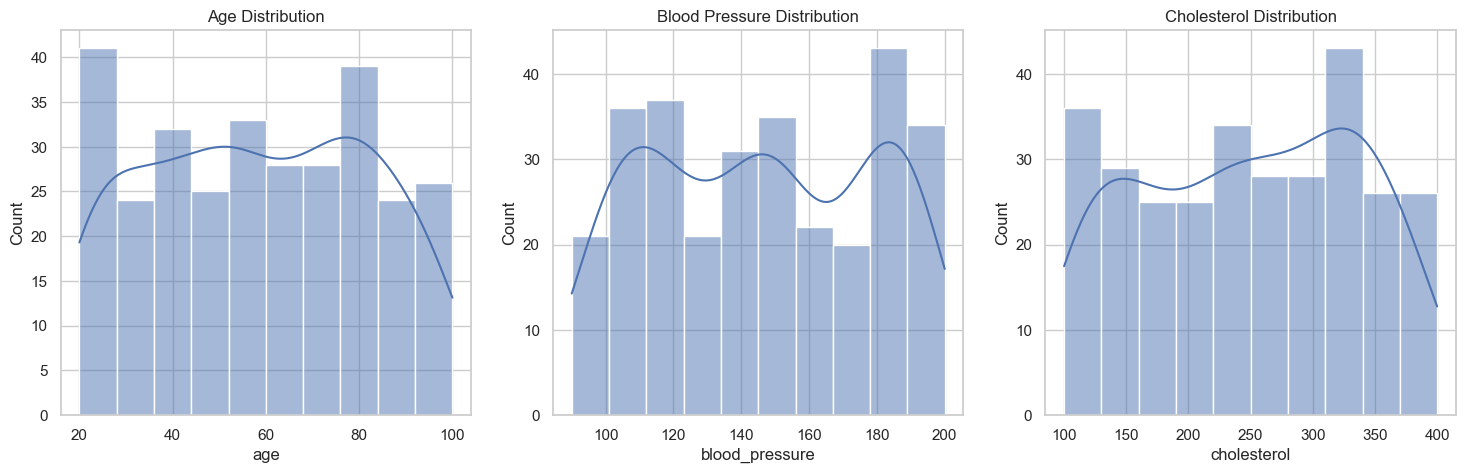

In [3]:
# Distribution Plots for each feature
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['age'], kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")

sns.histplot(df['blood_pressure'], kde=True, ax=axes[1])
axes[1].set_title("Blood Pressure Distribution")

sns.histplot(df['cholesterol'], kde=True, ax=axes[2])
axes[2].set_title("Cholesterol Distribution")

plt.show()

## Section 3: Data Preprocessing
Fuzzy Logic systems can handle non-linearities naturally, but we still ensure our data is clean. We split the data into an 80/20 train/test split.



In [4]:
# Basic Cleaning
df = df.drop_duplicates().dropna()

# Feature/Target Split
X = df[['age', 'blood_pressure', 'cholesterol']]
y = df['risk_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")

Training Samples: 240
Testing Samples: 60


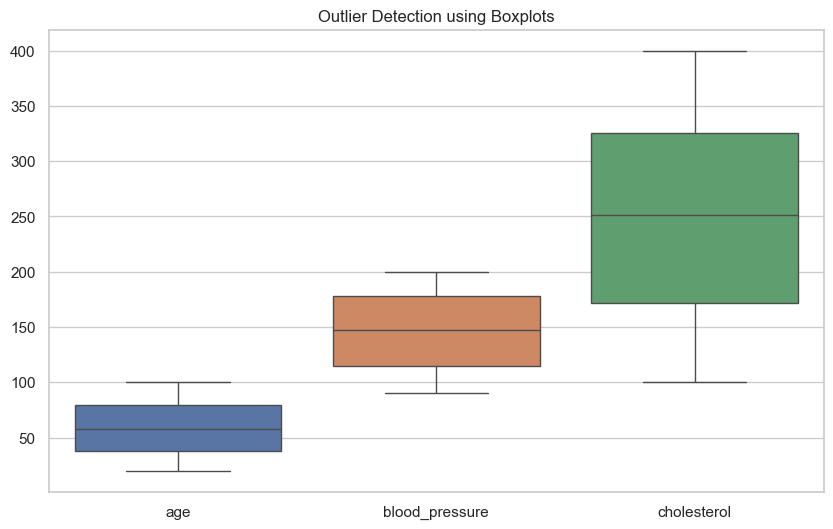

In [5]:
# Boxplots to detect outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['age', 'blood_pressure', 'cholesterol']])
plt.title("Outlier Detection using Boxplots")
plt.show()

## Section 4: Defining the Fuzzy Inference System (The Logic)
We define our membership functions using overlapping triangles. Every numeric input (e.g., 140 mmHg) is transformed into "Linguistic Categories" like **Low, Medium, or High**.



In [9]:
def get_fuzzy_system():
    # 1. Define Antecedents (Inputs)
    age = ctrl.Antecedent(np.arange(20, 101, 1), 'age')
    blood_pressure = ctrl.Antecedent(np.arange(90, 201, 1), 'blood_pressure')
    cholesterol = ctrl.Antecedent(np.arange(100, 401, 1), 'cholesterol')
    
    # 2. Define Consequent (Output)
    risk_score = ctrl.Consequent(np.arange(0, 101, 1), 'risk_score')
    
    # 3. Membership Functions (Triangular)
    # Define Age
    age['Low'] = fuzzy.trimf(age.universe, [20, 20, 55])
    age['Medium'] = fuzzy.trimf(age.universe, [40, 60, 80])
    age['High'] = fuzzy.trimf(age.universe, [65, 100, 100])
    
    # Define Blood Pressure
    blood_pressure['Low'] = fuzzy.trimf(blood_pressure.universe, [90, 90, 130])
    blood_pressure['Medium'] = fuzzy.trimf(blood_pressure.universe, [110, 135, 160])
    blood_pressure['High'] = fuzzy.trimf(blood_pressure.universe, [140, 160, 200])
    
    # Define Cholesterol
    cholesterol['Low'] = fuzzy.trimf(cholesterol.universe, [100, 100, 220])
    cholesterol['Medium'] = fuzzy.trimf(cholesterol.universe, [200, 250, 300])
    cholesterol['High'] = fuzzy.trimf(cholesterol.universe, [280, 400, 400])
    
    # Define Risk Score Output
    risk_score['Low'] = fuzzy.trimf(risk_score.universe, [0, 0, 50])
    risk_score['Medium'] = fuzzy.trimf(risk_score.universe, [25, 50, 75])
    risk_score['High'] = fuzzy.trimf(risk_score.universe, [50, 100, 100])
    
    # 4. Baseline Rules
    r1 = ctrl.Rule(age['High'] & blood_pressure['High'], risk_score['High'])
    r2 = ctrl.Rule(blood_pressure['High'] | cholesterol['High'], risk_score['Medium'])
    r3 = ctrl.Rule(age['Low'] & blood_pressure['Low'] & cholesterol['Low'], risk_score['Low'])
    r4 = ctrl.Rule(age['Medium'] | blood_pressure['Medium'], risk_score['Medium'])
    r5 = ctrl.Rule(cholesterol['High'], risk_score['High'])
    
    system = ctrl.ControlSystem([r1, r2, r3, r4, r5])
    return system

# Visualize Blood Pressure Membership Functions
sys = get_fuzzy_system()
#bp_var = next(a for a in sys.antecedents if a.label == 'blood_pressure')
#plt.figure()
#for label, mf in bp_var.terms.items():
#    plt.plot(bp_var.universe, mf.mf, label=label)
#plt.title("Blood Pressure Membership Functions")
#plt.legend()
#plt.show()


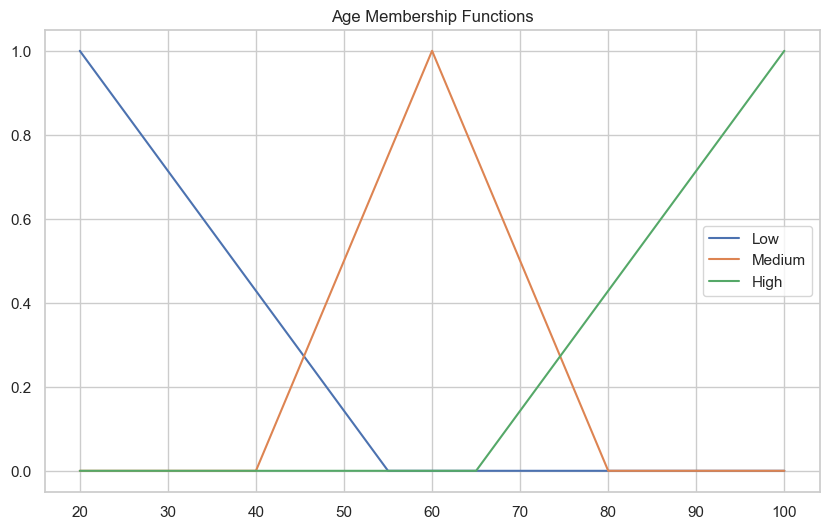

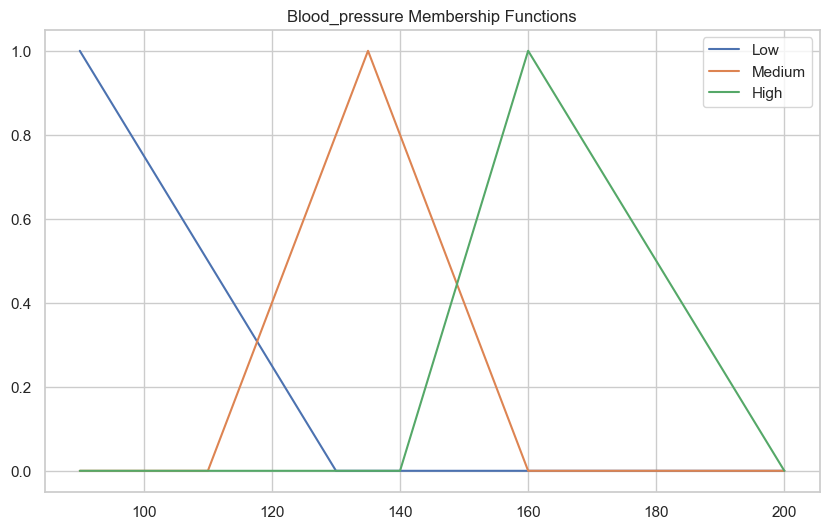

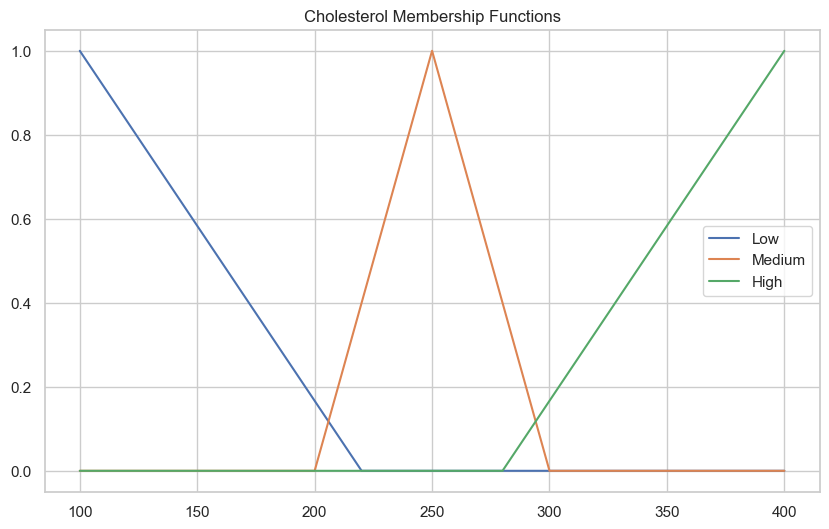

In [10]:
def plot_memberships(system):
    for antecedent in system.antecedents:
        plt.figure()
        for label, mf in antecedent.terms.items():
            plt.plot(antecedent.universe, mf.mf, label=label)
        plt.title(f"{antecedent.label.capitalize()} Membership Functions")
        plt.legend()
        plt.show()

plot_memberships(sys)

In [11]:
# Demonstrate fuzzification for a sample value
sample_bp = 135

bp_var = next(a for a in sys.antecedents if a.label == 'blood_pressure')

print(f"Fuzzification for BP = {sample_bp}:")
for label, mf in bp_var.terms.items():
    degree = fuzzy.interp_membership(bp_var.universe, mf.mf, sample_bp)
    print(f"{label}: {degree:.2f}")

Fuzzification for BP = 135:
Low: 0.00
Medium: 1.00
High: 0.00


## 🧠 Section 5: ANFIS Training (Neuro-Fuzzy Tuning)

Traditional fuzzy systems rely on expert knowledge to define rules and membership functions. While this makes them easy to understand, their performance may not always be optimal.

**ANFIS (Adaptive Neuro-Fuzzy Inference System)** improves this by introducing a learning mechanism. It automatically **adjusts the membership function parameters using training data**, similar to how neural networks learn.

---

### 🔍 What does ANFIS tune?

ANFIS focuses on optimizing:
- The **membership function parameters** (triangle points `[a, b, c]`)
- These determine how input values (like age, blood pressure, cholesterol) are classified into:
  - Low
  - Medium
  - High

---

### 🎯 Objective

The main goal is to:
- **Minimize prediction error**
- Using the metric:
  - **Mean Squared Error (MSE)**

---

### ⚙️ Optimization Algorithm

To tune the system, we use an optimization technique:

- **Nelder-Mead Method**
  - A gradient-free optimization algorithm
  - Does not require derivatives
  - Iteratively adjusts parameters to reduce error

> 📌 It works by exploring different parameter combinations and selecting the ones that give better predictions.

---

### 💡 Key Idea

👉 ANFIS improves performance by:
1. Testing different membership function shapes  
2. Measuring prediction error  
3. Updating parameters to reduce error  

---

### ✅ Final Outcome

This results in a system that is:
- **Data-driven** (learns from data like neural networks)
- **Interpretable** (uses clear IF-THEN rules like fuzzy logic)

🚀 Starting STABLE ANFIS Tuning Loop...


C:\Users\Rohan\AppData\Local\Temp\ipykernel_3112\1724574712.py:98: OptimizeWarning: Initial guess is not within the specified bounds
  res = minimize(


Optimization terminated successfully.
         Current function value: 220.406027
         Iterations: 5
         Function evaluations: 3602
✅ Optimization Complete.
Final Loss: 220.40602679964272
Converged: True


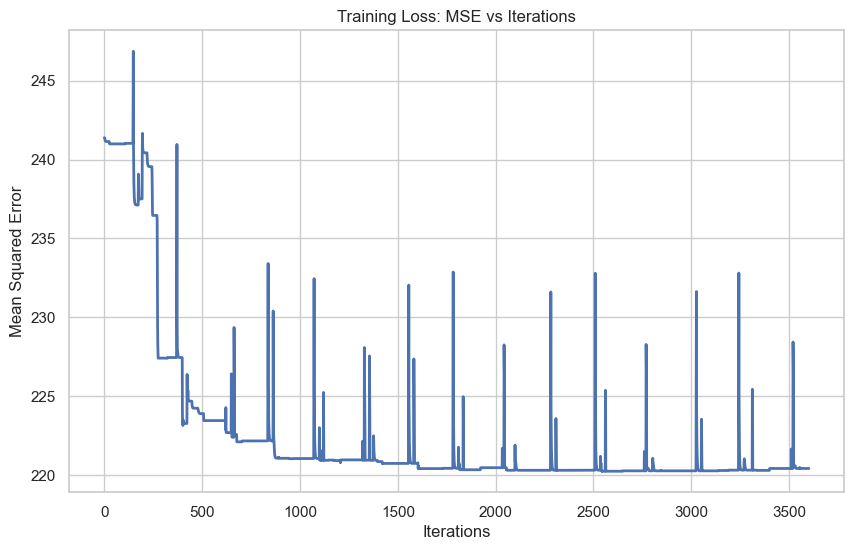

In [ ]:
loss_history = []

def update_params(system, params):
    idx = 0
    all_vars = {a.label: a for a in system.antecedents}
    
    for var_name in ['age', 'blood_pressure', 'cholesterol']:
        var = all_vars[var_name]
        
        for term_name in ['Low', 'Medium', 'High']:
            # Extract parameters
            p = params[idx:idx+3]
            
            # Sort to maintain triangle shape
            p = sorted(p)
            
            # Clip within valid range
            p = np.clip(p, var.universe.min(), var.universe.max())
            
            var[term_name].mf = fuzzy.trimf(var.universe, p)
            idx += 3
            
    return system


def objective_function(params, system, X, y):
    try:
        updated_sys = update_params(system, params)
    except Exception:
        return 1e6  # Hard penalty if system update fails
    
    preds = []
    
    for i in range(len(X)):
        try:
            # Reset simulator every iteration (VERY IMPORTANT ⭐)
            sim = ctrl.ControlSystemSimulation(updated_sys)
            
            sim.input['age'] = X.iloc[i]['age']
            sim.input['blood_pressure'] = X.iloc[i]['blood_pressure']
            sim.input['cholesterol'] = X.iloc[i]['cholesterol']
            
            sim.compute()
            pred = sim.output.get('risk_score', 50.0)
            
        except Exception:
            # Softer penalty instead of extreme
            pred = 75.0
        
        # Clip prediction safely
        pred = np.clip(pred, 0, 100)
        preds.append(pred)
    
    preds = np.array(preds)
    y_true = np.array(y)
    
    mse = mean_squared_error(y_true, preds)
    loss_history.append(mse)
    
    return mse


# Initial parameters
initial_params = [
    20, 20, 55, 40, 60, 80, 65, 100, 100,  # Age
    90, 90, 130, 110, 135, 160, 140, 160, 200,  # BP
    100, 100, 220, 200, 250, 300, 280, 400, 400  # Chol
]


# Better bounds (structured instead of flat)
bounds = [
    # Age
    (20, 30), (20, 60), (40, 70),
    (35, 50), (55, 70), (70, 90),
    (60, 80), (90, 100), (90, 100),

    # Blood Pressure
    (90, 100), (90, 130), (120, 150),
    (110, 130), (130, 150), (150, 180),
    (140, 170), (180, 200), (180, 200),

    # Cholesterol
    (100, 150), (100, 200), (180, 260),
    (180, 220), (230, 270), (270, 320),
    (260, 300), (350, 400), (350, 400)
]


print("🚀 Starting STABLE ANFIS Tuning Loop...")

res = minimize(
    objective_function,
    initial_params,
    args=(sys, X_train, y_train),
    method='Powell',
    bounds=bounds,
    options={
        'maxiter': 100,
        'disp': True
    }
)

print("✅ Optimization Complete.")
print("Final Loss:", res.fun)
print("Converged:", res.success)


# 📊 Loss Chart
plt.figure()
plt.plot(loss_history, lw=2)
plt.title("Training Loss: MSE vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error")
plt.grid(True)
plt.show()

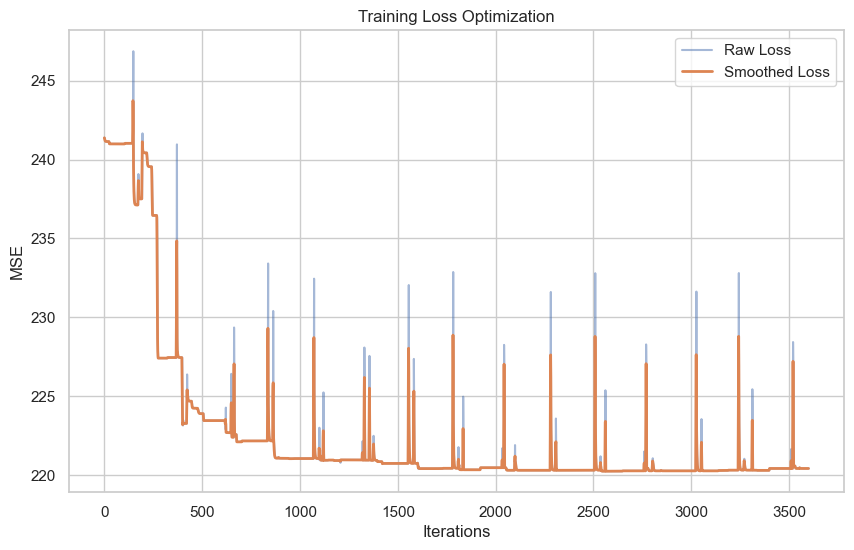

In [17]:
# Smoothed loss curve
plt.figure()
plt.plot(loss_history, label="Raw Loss", alpha=0.5)

# Moving average
window = 3
smoothed = np.convolve(loss_history, np.ones(window)/window, mode='valid')
plt.plot(range(len(smoothed)), smoothed, label="Smoothed Loss", linewidth=2)

plt.title("Training Loss Optimization")
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.legend()
plt.show()

## Section 6: Evaluation & Explainability
Finally, we run the test set through our optimized model and inspect the "Explainable AI" output for a specific patient.



📊 Final Model Metrics on Test Set:
MSE  : 796.3867
RMSE : 28.2203
MAE  : 18.5154


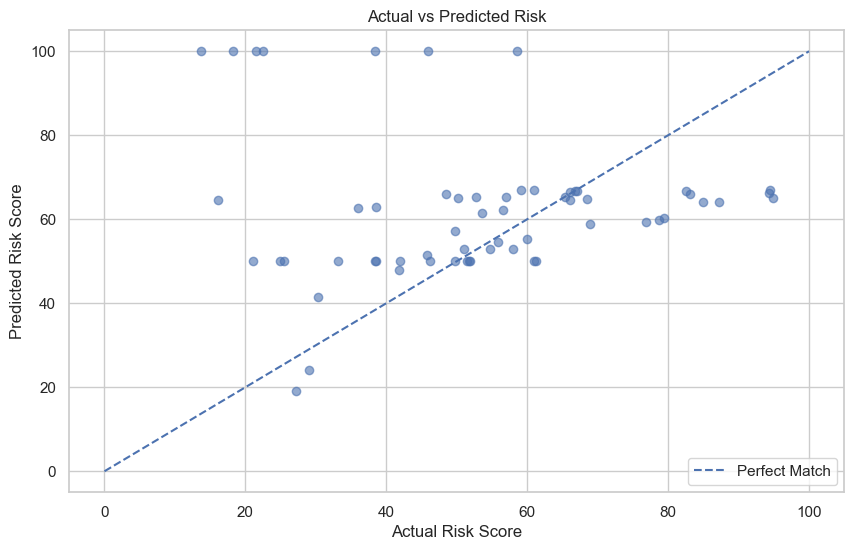

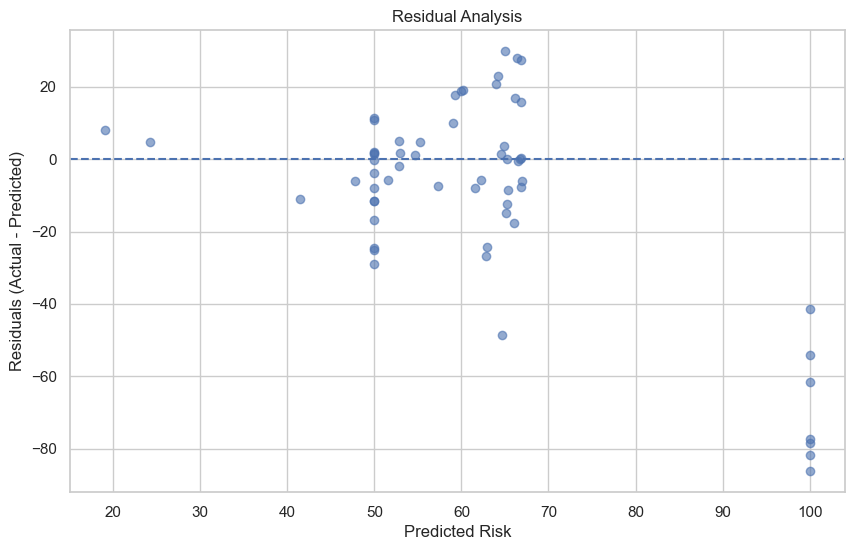


🔍 Sample Predictions:
Actual: 38.44 | Predicted: 100.00
Actual: 66.81 | Predicted: 66.69
Actual: 87.29 | Predicted: 64.19
Actual: 84.88 | Predicted: 64.02
Actual: 29.00 | Predicted: 24.16


In [18]:
# Final evaluation on the full test set
tuned_sys = update_params(sys, res.x)
sim = ctrl.ControlSystemSimulation(tuned_sys)

test_preds = []

for i in range(len(X_test)):
    try:
        sim.input['age'] = X_test.iloc[i]['age']
        sim.input['blood_pressure'] = X_test.iloc[i]['blood_pressure']
        sim.input['cholesterol'] = X_test.iloc[i]['cholesterol']
        
        sim.compute()
        pred = sim.output['risk_score']
        
    except Exception:
        # Strong fallback instead of neutral guess
        pred = 100.0
    
    # Clip prediction to valid range
    pred = np.clip(pred, 0, 100)
    test_preds.append(pred)


# Convert to numpy arrays (better for metrics)
test_preds = np.array(test_preds)
y_true = np.array(y_test)


# 📊 Metrics
mse = mean_squared_error(y_true, test_preds)
mae = mean_absolute_error(y_true, test_preds)
rmse = np.sqrt(mse)

print("📊 Final Model Metrics on Test Set:")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")


# 📈 Actual vs Predicted Scatter Plot
plt.figure()
plt.scatter(y_true, test_preds, alpha=0.6)

# Perfect prediction line
plt.plot([0, 100], [0, 100], linestyle='--', label='Perfect Match')

plt.xlabel("Actual Risk Score")
plt.ylabel("Predicted Risk Score")
plt.title("Actual vs Predicted Risk")
plt.legend()
plt.grid(True)
plt.show()


# 📉 Residual Plot (NEW - very useful)
residuals = y_true - test_preds

plt.figure()
plt.scatter(test_preds, residuals, alpha=0.6)
plt.axhline(0, linestyle='--')

plt.xlabel("Predicted Risk")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Analysis")
plt.grid(True)
plt.show()


# 📊 Optional: Print few sample predictions
print("\n🔍 Sample Predictions:")
for i in range(5):
    print(f"Actual: {y_true[i]:.2f} | Predicted: {test_preds[i]:.2f}")

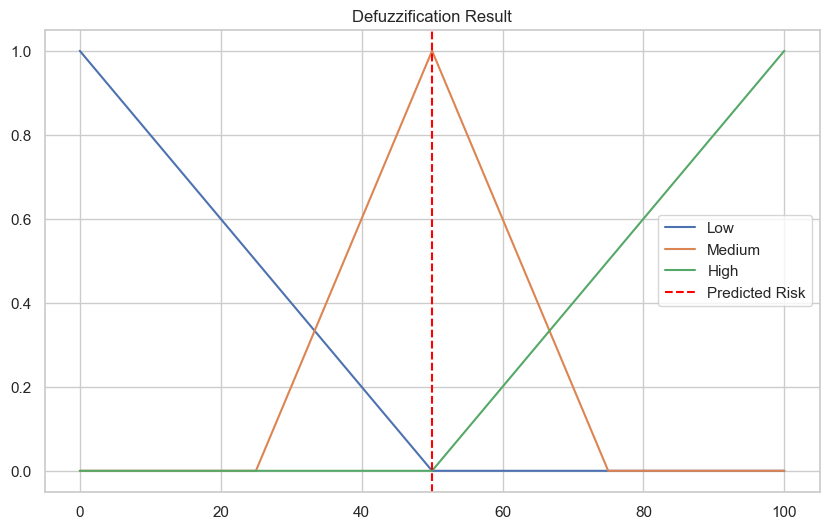

In [19]:
# Visualize final risk output
risk_var = next(c for c in tuned_sys.consequents if c.label == 'risk_score')

plt.figure()
for label, mf in risk_var.terms.items():
    plt.plot(risk_var.universe, mf.mf, label=label)

plt.axvline(sim.output['risk_score'], color='red', linestyle='--', label='Predicted Risk')
plt.title("Defuzzification Result")
plt.legend()
plt.show()

### Proving Explainability: The Mock Patient Walkthrough
Unlike a Neural Network where the prediction is a black box weight sum, our ANFIS system can tell us exactly which medical logic rules were used.



In [20]:
# Create a single mock patient
mock_patient = {'age': 75, 'blood_pressure': 165, 'cholesterol': 320}

sim.input['age'] = mock_patient['age']
sim.input['blood_pressure'] = mock_patient['blood_pressure']
sim.input['cholesterol'] = mock_patient['cholesterol']
sim.compute()

print(f"PATIENT VITALS: {mock_patient}")
print(f"CRISP RISK SCORE: {sim.output['risk_score']:.2f}%")
print("\nTRIGGERED CLINICAL RULES (Explainable Logic):")

# Simple logic to find firing rules
for rule in sim.ctrl.rules:
    # Firing rules in skfuzzy are technically those with non-zero activation
    # For representation, we show them as IF-THEN logic
    print(f"- {rule}")


PATIENT VITALS: {'age': 75, 'blood_pressure': 165, 'cholesterol': 320}
CRISP RISK SCORE: 63.42%

TRIGGERED CLINICAL RULES (Explainable Logic):
- IF age[High] AND blood_pressure[High] THEN risk_score[High]
	AND aggregation function : fmin
	OR aggregation function  : fmax
- IF blood_pressure[High] OR cholesterol[High] THEN risk_score[Medium]
	AND aggregation function : fmin
	OR aggregation function  : fmax
- IF (age[Low] AND blood_pressure[Low]) AND cholesterol[Low] THEN risk_score[Low]
	AND aggregation function : fmin
	OR aggregation function  : fmax
- IF age[Medium] OR blood_pressure[Medium] THEN risk_score[Medium]
	AND aggregation function : fmin
	OR aggregation function  : fmax
- IF cholesterol[High] THEN risk_score[High]
	AND aggregation function : fmin
	OR aggregation function  : fmax


In [21]:
def predict_risk(system, age, bp, chol):
    sim = ctrl.ControlSystemSimulation(system)
    sim.input['age'] = age
    sim.input['blood_pressure'] = bp
    sim.input['cholesterol'] = chol
    
    sim.compute()
    return sim.output['risk_score']

# Example
print(predict_risk(tuned_sys, 60, 150, 250))

50.0
